# GridCast Europe – A³-Phase: Modellentwicklung

**QUA³CK-Phase:** A³ – *Algorithm Selection, Adapting Features, Adjusting Hyperparameters*  
**Fassung:** 25.07.2026  
**Kernländer:** Deutschland (`DE`), Frankreich (`FR`), Polen (`PL`)  
**Entwicklungsfenster:** Training 2015–2017, Validierung 2018  
**Testjahr 2019:** unmittelbar nach dem Einlesen ausgeschlossen; nicht für Auswahl oder Tuning verwendet

Dieses Notebook entwickelt die Baselines und Regressionsmodelle für GridCast
Europe. Es setzt die im Q-Notebook vorab festgelegten Regeln um:

- länderspezifischer Mittelwert und Kalenderdurchschnitt als Baselines,
- Ridge-Regression als interpretierbares lineares Modell,
- Histogram Gradient Boosting als nichtlineares Modell,
- Feature-Ablationen für Wetter und Feiertage,
- begrenzte Hyperparameterwahl ausschließlich anhand von 2018,
- primäre Auswahl nach länderweise gleichgewichtetem Makro-nMAE.

Die ausgewählte Konfiguration wird am Ende eingefroren. Die einmalige
Testauswertung auf 2019 gehört erst in die C-Phase.


## 1. Methodische Grenze: Entwicklung statt Testauswertung

Das Notebook darf Modell- und Featureentscheidungen anhand von 2018 treffen,
aber noch keine Aussage über die endgültige Testgüte machen.

| Block | Zeitraum | Verwendung in A³ |
|---|---|---|
| Training | 2015–2017 | Baseline-Durchschnitte, Zielskalierung, Preprocessing und Modellparameter lernen |
| Validierung | 2018 | Features, Modellfamilie und Hyperparameter auswählen |
| Test | 2019 | **unmittelbar nach dem Einlesen ausschließen; nicht vorhersagen, auswerten oder zum Tuning verwenden** |

Weitere Leakage-Regeln:

- keine zufällige Aufteilung,
- keine Zielwerte aus 2018 beim Fit,
- Zielskalierung nur aus Trainingsmitteln,
- keine TSO-Prognosen und keine Last-Lags,
- tatsächliches Reanalysewetter 2018 wird als historisches Backtest-Feature
  verwendet und nicht als echte Wettervorhersage bezeichnet.


In [1]:
from __future__ import annotations

import json
import sys
import time
from pathlib import Path

import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

try:
    from IPython.display import Markdown
except ImportError:
    class Markdown(str):
        def _repr_markdown_(self):
            return str(self)

PROJECT_ROOT = Path.cwd()
if not (PROJECT_ROOT / "src" / "gridcast").is_dir():
    PROJECT_ROOT = Path.cwd().parent
if not (PROJECT_ROOT / "src" / "gridcast").is_dir():
    raise FileNotFoundError("Projektwurzel mit src/gridcast wurde nicht gefunden.")

sys.path.insert(0, str(PROJECT_ROOT / "src"))

from gridcast.modeling import (
    CalendarBaseline,
    CountryMeanBaseline,
    add_modeling_features,
    make_hgb_estimator,
    make_ridge_estimator,
    regression_metrics,
    relative_improvement,
)

sns.set_theme(style="whitegrid", context="notebook")
pd.set_option("display.max_columns", 30)
pd.set_option("display.max_colwidth", 100)
RANDOM_STATE = 42

print(f"Projektwurzel: {PROJECT_ROOT}")
print(f"Python: {sys.version.split()[0]}")
print(f"Pandas: {pd.__version__}")


Projektwurzel: /workspace/scratch/b16d81756317/gridcast_work
Python: 3.12.13
Pandas: 2.2.3


## 2. Entwicklungsdaten laden und Testblock abtrennen

Verwendet wird ausschließlich der in der U-Phase erzeugte Modelldatensatz.
Die Rohdaten müssen für A³ nicht erneut gejoint werden. Unmittelbar nach dem
Einlesen werden nur `train` und `validation` übernommen; alle weiteren
Operationen arbeiten mit dieser reduzierten Tabelle.

Zusätzlich wird ein nationales Feiertagsmerkmal ergänzt. Es ist für ein
Kalenderdatum im Voraus bekannt und verursacht daher kein Leakage. Abgebildet
werden landesweite Feiertage; regionale deutsche Feiertage bleiben eine
dokumentierte Grenze.


In [2]:
MODEL_DATA_PATH = (
    PROJECT_ROOT / "data" / "processed" / "opsd_model_data_2015_2019.csv.gz"
)
if not MODEL_DATA_PATH.is_file():
    raise FileNotFoundError(
        "Der Modelldatensatz fehlt. Bitte zuerst 01_data_import_merge_eda.ipynb ausführen."
    )

DEVELOPMENT_COLUMNS = [
    "utc_timestamp",
    "country",
    "load_mw",
    "temperature_c",
    "radiation_direct_wm2",
    "radiation_diffuse_wm2",
    "local_date",
    "local_hour",
    "local_weekday",
    "local_month",
    "is_weekend",
    "season",
    "hour_sin",
    "hour_cos",
    "weekday_sin",
    "weekday_cos",
    "year_sin",
    "year_cos",
    "temperature_sq",
    "heating_degrees",
    "cooling_degrees",
    "split",
]

source_data = pd.read_csv(
    MODEL_DATA_PATH,
    usecols=DEVELOPMENT_COLUMNS,
    parse_dates=["utc_timestamp"],
)
development_data = source_data.loc[
    source_data["split"].isin(["train", "validation"])
].copy()
del source_data

development_data = add_modeling_features(development_data)
train = development_data.loc[development_data["split"].eq("train")].copy()
validation = development_data.loc[
    development_data["split"].eq("validation")
].copy()

assert set(development_data["split"]) == {"train", "validation"}
assert development_data["utc_timestamp"].dt.year.max() == 2018
assert train["utc_timestamp"].dt.year.between(2015, 2017).all()
assert validation["utc_timestamp"].dt.year.eq(2018).all()
assert development_data["load_mw"].notna().all()

split_summary = (
    development_data.groupby(["split", "country"], observed=True)
    .agg(
        rows=("load_mw", "size"),
        start_utc=("utc_timestamp", "min"),
        end_utc=("utc_timestamp", "max"),
        mean_load_mw=("load_mw", "mean"),
        holidays=("is_holiday", "sum"),
    )
    .reset_index()
)
display(split_summary)
print(f"Entwicklungszeilen: {len(development_data):,}".replace(",", "."))
print("Testzeilen im verwendeten Entwicklungs-DataFrame: 0")


,split,country,rows,start_utc,end_utc,mean_load_mw,holidays
0,train,DE,26304,2015-01-01 00:00:00+00:00,2017-12-31 23:00:00+00:00,55451.940922,672
1,train,FR,26290,2015-01-01 01:00:00+00:00,2017-12-31 23:00:00+00:00,54165.927558,791
2,train,PL,26303,2015-01-01 01:00:00+00:00,2017-12-31 23:00:00+00:00,18784.064685,791
3,validation,DE,8760,2018-01-01 00:00:00+00:00,2018-12-31 23:00:00+00:00,56951.509817,216
4,validation,FR,8749,2018-01-01 00:00:00+00:00,2018-12-31 23:00:00+00:00,53807.978512,264
5,validation,PL,8760,2018-01-01 00:00:00+00:00,2018-12-31 23:00:00+00:00,19531.910088,264


Entwicklungszeilen: 105.166
Testzeilen im verwendeten Entwicklungs-DataFrame: 0


## 3. Metriken und länderweise Zielskalierung

Absolute MW-Fehler bleiben für die praktische Interpretation erhalten.
Die Modellauswahl erfolgt jedoch über den Makro-nMAE:

$$
\mathrm{nMAE}_c
=
\frac{
\frac{1}{n_c}\sum_{i=1}^{n_c}|y_i-\widehat y_i|
}{
\frac{1}{n_c}\sum_{i=1}^{n_c}|y_i|
}
$$

$$
\mathrm{Makro\text{-}nMAE}
=
\frac{1}{|C|}
\sum_{c \in C}\mathrm{nMAE}_c
$$

Dadurch gehen DE, FR und PL mit gleichem Gewicht in die Auswahl ein.

Die ML-Modelle lernen zusätzlich eine länderweise skalierte Zielvariable:

$$
y'_{c,t}=\frac{y_{c,t}}{\overline y_{c,\mathrm{Train}}}
$$

Die Skalen stammen ausschließlich aus 2015–2017. Vorhersagen werden danach
wieder in MW zurücktransformiert. So dominiert ein großes Stromsystem das
gemeinsame Trainingsziel nicht allein wegen seiner Größenordnung.


In [3]:
y_train = train["load_mw"].to_numpy()
y_validation = validation["load_mw"].to_numpy()

all_summaries: list[dict] = []
all_country_metrics: list[pd.DataFrame] = []
predictions: dict[str, np.ndarray] = {}


def record_prediction(
    name: str,
    prediction: np.ndarray,
    *,
    family: str,
    feature_set: str,
    fit_seconds: float = 0.0,
) -> tuple[dict, pd.DataFrame]:
    summary, by_country = regression_metrics(
        y_validation,
        prediction,
        validation["country"],
    )
    row = {
        "model": name,
        "family": family,
        "feature_set": feature_set,
        "fit_seconds": fit_seconds,
        **summary,
    }
    by_country = by_country.assign(model=name)
    predictions[name] = np.asarray(prediction, dtype=float)
    return row, by_country


def format_frame(frame: pd.DataFrame, formats: dict[str, str]) -> pd.DataFrame:
    result = frame.copy()
    for column, number_format in formats.items():
        if column in result.columns:
            result[column] = result[column].map(
                lambda value: number_format.format(value)
            )
    return result


country_scales = (
    train.groupby("country", observed=True)["load_mw"]
    .mean()
    .rename("training_mean_mw")
    .reset_index()
)
display(country_scales)


,country,training_mean_mw
0,DE,55451.940922
1,FR,54165.927558
2,PL,18784.064685


## 4. Leakage-freie Baselines

### Baseline 1: länderspezifischer Mittelwert

Für jede Stunde eines Landes wird dessen Trainingsmittel vorhergesagt. Diese
Baseline ist absichtlich trivial.

### Baseline 2: Kalenderdurchschnitt

Die stärkere Baseline verwendet zunächst:

> Land × Monat × Tagtyp × lokale Stunde

`Tagtyp` unterscheidet Werktag, Wochenende und nationalen Feiertag. Gruppen
mit weniger als drei Trainingsbeobachtungen verwenden nacheinander:

1. Land × Monat × Wochenendklasse × Stunde,
2. Land × Wochenendklasse × Stunde,
3. Land × Stunde,
4. Ländermittelwert.

Alle Durchschnitte stammen ausschließlich aus 2015–2017.


In [4]:
mean_baseline = CountryMeanBaseline().fit(train, y_train)
calendar_baseline = CalendarBaseline(min_group_size=3).fit(train, y_train)

mean_prediction = mean_baseline.predict(validation)
calendar_prediction, calendar_levels = calendar_baseline.predict_with_levels(
    validation
)

mean_summary, mean_by_country = record_prediction(
    "Ländermittelwert",
    mean_prediction,
    family="Baseline",
    feature_set="Land",
)
calendar_summary, calendar_by_country = record_prediction(
    "Kalender-Baseline",
    calendar_prediction,
    family="Baseline",
    feature_set="Land + Monat + Tagtyp + Stunde",
)
all_summaries.extend([mean_summary, calendar_summary])
all_country_metrics.extend([mean_by_country, calendar_by_country])

baseline_table = pd.DataFrame([mean_summary, calendar_summary])[
    ["model", "MAE_MW", "RMSE_MW", "macro_nMAE", "sMAPE_pct", "R2"]
]
baseline_table["Verbesserung_vs_Mittelwert_pct"] = [
    0.0,
    relative_improvement(
        calendar_summary["macro_nMAE"],
        mean_summary["macro_nMAE"],
    ),
]
display(
    format_frame(
        baseline_table,
        {
            "MAE_MW": "{:,.1f}",
            "RMSE_MW": "{:,.1f}",
            "macro_nMAE": "{:.4f}",
            "sMAPE_pct": "{:.2f}",
            "R2": "{:.4f}",
            "Verbesserung_vs_Mittelwert_pct": "{:.1f}",
        },
    )
)

fallback_usage = (
    pd.Series(calendar_levels, name="Rückfallebene")
    .value_counts()
    .rename_axis("Rückfallebene")
    .reset_index(name="Validierungszeilen")
)
fallback_usage["Anteil_pct"] = (
    100 * fallback_usage["Validierungszeilen"] / len(validation)
)
display(format_frame(fallback_usage, {"Anteil_pct": "{:.3f}"}))


,model,MAE_MW,RMSE_MW,macro_nMAE,sMAPE_pct,R2,Verbesserung_vs_Mittelwert_pct
0,Ländermittelwert,"7,102.5","9,173.0",0.1597,16.09,0.7729,0.0
1,Kalender-Baseline,"2,489.2","3,607.4",0.0576,5.76,0.9649,64.0


,Rückfallebene,Validierungszeilen,Anteil_pct
0,Land × Monat × Tagtyp × Stunde,26196,99.722
1,Land × Monat × Wochenendklasse × Stunde,73,0.278


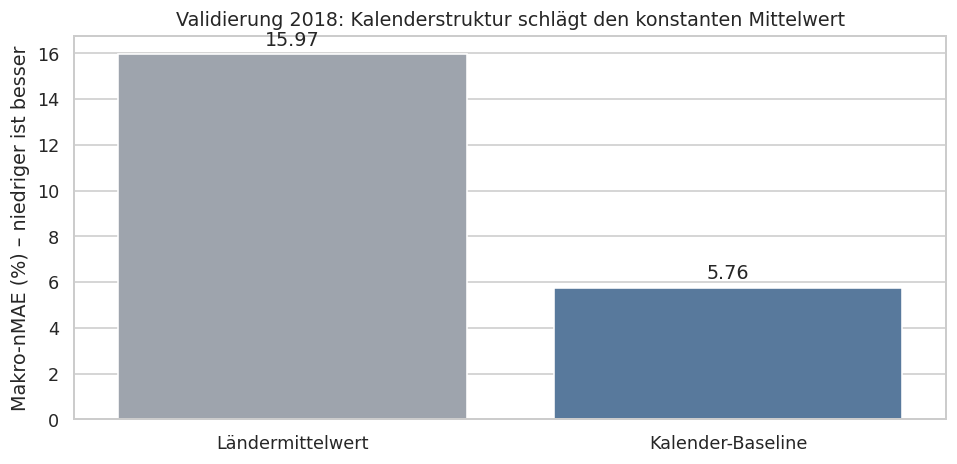

In [5]:
fig, ax = plt.subplots(figsize=(8.5, 4.2))
baseline_plot = baseline_table.copy()
baseline_plot["macro_nMAE_pct"] = 100 * baseline_plot["macro_nMAE"]
sns.barplot(
    data=baseline_plot,
    x="model",
    y="macro_nMAE_pct",
    hue="model",
    legend=False,
    palette=["#9ca3af", "#4c78a8"],
    ax=ax,
)
ax.set(
    title="Validierung 2018: Kalenderstruktur schlägt den konstanten Mittelwert",
    xlabel="",
    ylabel="Makro-nMAE (%) – niedriger ist besser",
)
for container in ax.containers:
    ax.bar_label(container, fmt="%.2f", padding=3)
plt.tight_layout()
plt.show()


## 5. Modellfamilien und Featuregruppen

### Ridge-Regression

Die Ridge-Regression ist der interpretierbare lineare Vergleich. Ein
One-Hot-Merkmal für `Land × Monat × Tagtyp × Stunde` bildet die
Kalenderstruktur ab; numerische Merkmale werden standardisiert.

### Histogram Gradient Boosting

Das Boosting-Modell kann nichtlineare Schwellen und Interaktionen zwischen
Land, Kalender und Wetter lernen. Optimiert wird der absolute Fehler der
länderskalierten Zielvariable.

### Ablationslogik

| Featuregruppe | Inhalt |
|---|---|
| Kalender | Land, lokale Stunde/Wochentag/Monat, Wochenende, zyklische Kodierungen |
| Feiertag | landesweit bekannter Feiertagsindikator |
| Wetter | Temperatur, Temperaturquadrat, Heating/Cooling Degrees, direkte und diffuse Strahlung |

Vergleiche mit und ohne Merkmalsgruppe zeigen, ob eine Erweiterung auf 2018
tatsächlich zusätzlichen Nutzen liefert.


In [6]:
ridge_rows: list[dict] = []
best_ridge_model = None
best_ridge_prediction = None
best_ridge_row = None

for include_weather in (False, True):
    feature_label = "Kalender + Feiertag" + (
        " + Wetter" if include_weather else ""
    )
    for alpha in (0.1, 1.0, 10.0, 100.0):
        estimator = make_ridge_estimator(
            alpha=alpha,
            include_weather=include_weather,
            include_holiday=True,
        )
        started = time.perf_counter()
        estimator.fit(train, y_train)
        prediction = estimator.predict(validation)
        fit_seconds = time.perf_counter() - started
        summary, _ = regression_metrics(
            y_validation,
            prediction,
            validation["country"],
        )
        row = {
            "model": f"Ridge α={alpha:g}",
            "family": "Ridge",
            "feature_set": feature_label,
            "alpha": alpha,
            "fit_seconds": fit_seconds,
            **summary,
        }
        ridge_rows.append(row)
        if best_ridge_row is None or row["macro_nMAE"] < best_ridge_row["macro_nMAE"]:
            best_ridge_row = row
            best_ridge_model = estimator
            best_ridge_prediction = prediction

ridge_results = pd.DataFrame(ridge_rows).sort_values("macro_nMAE")
display(
    format_frame(
        ridge_results[
            [
                "feature_set",
                "alpha",
                "MAE_MW",
                "RMSE_MW",
                "macro_nMAE",
                "sMAPE_pct",
                "R2",
                "fit_seconds",
            ]
        ],
        {
            "MAE_MW": "{:,.1f}",
            "RMSE_MW": "{:,.1f}",
            "macro_nMAE": "{:.4f}",
            "sMAPE_pct": "{:.2f}",
            "R2": "{:.4f}",
            "fit_seconds": "{:.2f}",
        },
    )
)


,feature_set,alpha,MAE_MW,RMSE_MW,macro_nMAE,sMAPE_pct,R2,fit_seconds
4,Kalender + Feiertag + Wetter,0.1,"2,132.0","2,989.7",0.0498,5.06,0.9759,0.20
5,Kalender + Feiertag + Wetter,1.0,"2,131.5","2,987.6",0.0498,5.05,0.9759,0.21
6,Kalender + Feiertag + Wetter,10.0,"2,318.4","3,230.0",0.0540,5.46,0.9718,0.15
1,Kalender + Feiertag,1.0,"2,374.1","3,461.2",0.0549,5.45,0.9677,0.10
0,Kalender + Feiertag,0.1,"2,377.3","3,476.3",0.0549,5.45,0.9674,0.11
2,Kalender + Feiertag,10.0,"2,546.4","3,622.3",0.0588,5.86,0.9646,0.10
7,Kalender + Feiertag + Wetter,100.0,"3,350.3","4,654.4",0.0757,7.66,0.9415,0.15
3,Kalender + Feiertag,100.0,"3,502.9","4,857.1",0.0792,7.97,0.9363,0.09


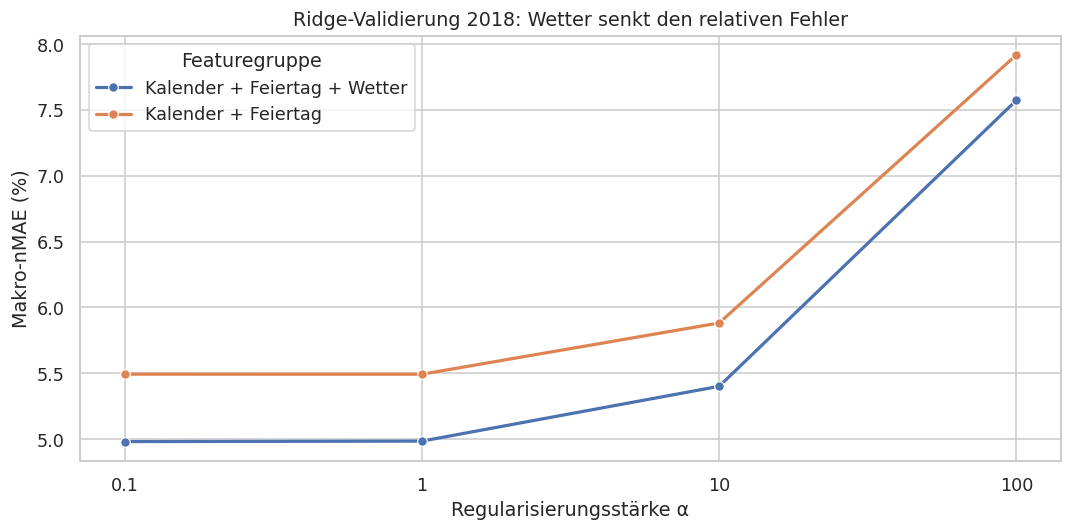

In [7]:
fig, ax = plt.subplots(figsize=(9.5, 4.8))
ridge_plot = ridge_results.copy()
ridge_plot["alpha_label"] = ridge_plot["alpha"].map(lambda value: f"{value:g}")
ridge_plot["macro_nMAE_pct"] = 100 * ridge_plot["macro_nMAE"]
sns.lineplot(
    data=ridge_plot,
    x="alpha_label",
    y="macro_nMAE_pct",
    hue="feature_set",
    marker="o",
    linewidth=2,
    ax=ax,
)
ax.set(
    title="Ridge-Validierung 2018: Wetter senkt den relativen Fehler",
    xlabel="Regularisierungsstärke α",
    ylabel="Makro-nMAE (%)",
)
ax.legend(title="Featuregruppe")
plt.tight_layout()
plt.show()


## 6. Feature-Ablation beim nichtlinearen Modell

Vor dem Hyperparametertuning wird mit einer festen, plausiblen
Boosting-Konfiguration isoliert geprüft:

- Was leisten Wettermerkmale zusätzlich?
- Verbessert der Feiertagsindikator die zeitliche Generalisierung?

Nur wenn eine Merkmalsgruppe den Validierungsfehler senkt, wird sie in die
anschließende Hyperparametersuche übernommen.


In [8]:
ablation_rows: list[dict] = []
ablation_models: dict[tuple[bool, bool], object] = {}
ablation_predictions: dict[tuple[bool, bool], np.ndarray] = {}

for include_holiday in (False, True):
    for include_weather in (False, True):
        estimator = make_hgb_estimator(
            include_weather=include_weather,
            include_holiday=include_holiday,
            learning_rate=0.1,
            max_leaf_nodes=63,
            max_iter=300,
            min_samples_leaf=80,
            l2_regularization=1.0,
            random_state=RANDOM_STATE,
        )
        started = time.perf_counter()
        estimator.fit(train, y_train)
        prediction = estimator.predict(validation)
        fit_seconds = time.perf_counter() - started
        summary, _ = regression_metrics(
            y_validation,
            prediction,
            validation["country"],
        )
        label = "Kalender"
        if include_holiday:
            label += " + Feiertag"
        if include_weather:
            label += " + Wetter"
        row = {
            "feature_set": label,
            "include_holiday": include_holiday,
            "include_weather": include_weather,
            "fit_seconds": fit_seconds,
            **summary,
        }
        ablation_rows.append(row)
        ablation_models[(include_holiday, include_weather)] = estimator
        ablation_predictions[(include_holiday, include_weather)] = prediction

ablation_results = pd.DataFrame(ablation_rows).sort_values("macro_nMAE")
calendar_only_error = ablation_results.loc[
    ablation_results["feature_set"].eq("Kalender"), "macro_nMAE"
].iloc[0]
holiday_weather_error = ablation_results.loc[
    ablation_results["feature_set"].eq("Kalender + Feiertag + Wetter"),
    "macro_nMAE",
].iloc[0]

display(
    format_frame(
        ablation_results[
            [
                "feature_set",
                "MAE_MW",
                "RMSE_MW",
                "macro_nMAE",
                "sMAPE_pct",
                "R2",
                "fit_seconds",
            ]
        ],
        {
            "MAE_MW": "{:,.1f}",
            "RMSE_MW": "{:,.1f}",
            "macro_nMAE": "{:.4f}",
            "sMAPE_pct": "{:.2f}",
            "R2": "{:.4f}",
            "fit_seconds": "{:.2f}",
        },
    )
)
print(
    "Fehlerreduktion Kalender → Kalender + Feiertag + Wetter: "
    f"{relative_improvement(holiday_weather_error, calendar_only_error):.1f} %"
)


,feature_set,MAE_MW,RMSE_MW,macro_nMAE,sMAPE_pct,R2,fit_seconds
3,Kalender + Feiertag + Wetter,"1,389.8","1,879.2",0.0336,3.41,0.9905,3.41
1,Kalender + Wetter,"1,460.6","2,132.0",0.0350,3.56,0.9877,2.60
2,Kalender + Feiertag,"2,175.3","3,564.8",0.0483,4.70,0.9657,2.26
0,Kalender,"2,252.6","3,663.6",0.0500,4.89,0.9638,2.29


Fehlerreduktion Kalender → Kalender + Feiertag + Wetter: 32.9 %


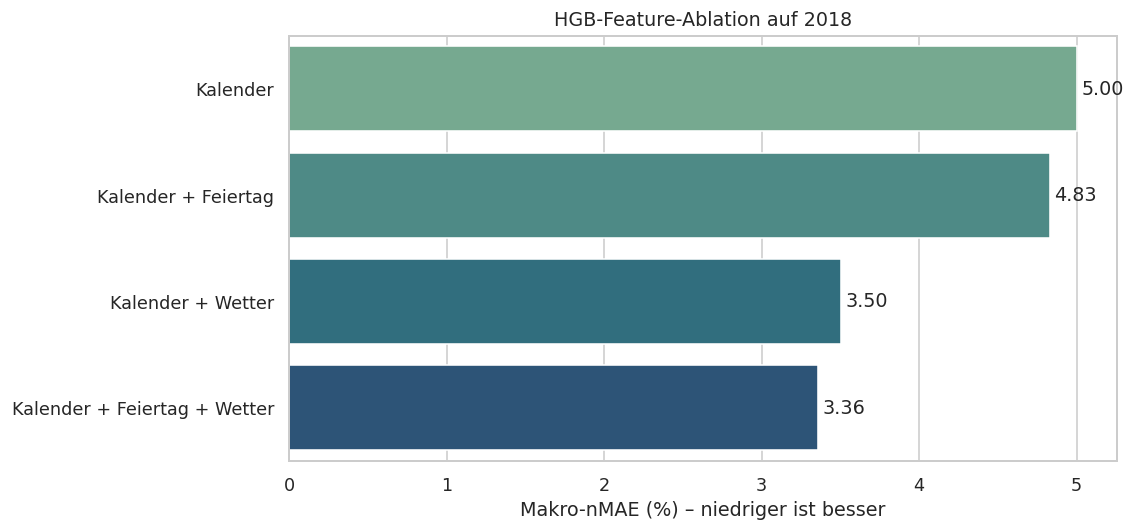

In [9]:
fig, ax = plt.subplots(figsize=(10, 4.8))
ablation_plot = ablation_results.sort_values("macro_nMAE", ascending=False).copy()
ablation_plot["macro_nMAE_pct"] = 100 * ablation_plot["macro_nMAE"]
sns.barplot(
    data=ablation_plot,
    y="feature_set",
    x="macro_nMAE_pct",
    hue="feature_set",
    legend=False,
    palette="crest",
    ax=ax,
)
ax.set(
    title="HGB-Feature-Ablation auf 2018",
    xlabel="Makro-nMAE (%) – niedriger ist besser",
    ylabel="",
)
for container in ax.containers:
    ax.bar_label(container, fmt="%.2f", padding=3)
plt.tight_layout()
plt.show()


## 7. Begrenzte Hyperparameteroptimierung

Die Ablation entscheidet über die Featuregruppen. Danach wird nur das
vollständige Boosting-Modell mit Feiertag und Wetter abgestimmt.

Geprüft werden:

- Lernrate: `0.05`, `0.10`,
- maximale Blattknoten: `31`, `63`, `127`,
- minimale Beobachtungen pro Blatt: `30`, `80`.

Konstant bleiben:

- `loss="absolute_error"`,
- `max_iter=300`,
- `l2_regularization=1.0`,
- `random_state=42`,
- kein Early Stopping auf einem intern zufällig abgetrennten Block.

Zwölf Kandidaten sind für den Prüfungsumfang ausreichend, bleiben
nachvollziehbar und vermeiden eine unkontrollierte Suche.


In [10]:
hgb_rows: list[dict] = []
best_hgb_model = None
best_hgb_prediction = None
best_hgb_row = None

for learning_rate in (0.05, 0.1):
    for max_leaf_nodes in (31, 63, 127):
        for min_samples_leaf in (30, 80):
            estimator = make_hgb_estimator(
                include_weather=True,
                include_holiday=True,
                learning_rate=learning_rate,
                max_leaf_nodes=max_leaf_nodes,
                max_iter=300,
                min_samples_leaf=min_samples_leaf,
                l2_regularization=1.0,
                loss="absolute_error",
                random_state=RANDOM_STATE,
            )
            started = time.perf_counter()
            estimator.fit(train, y_train)
            prediction = estimator.predict(validation)
            fit_seconds = time.perf_counter() - started
            summary, _ = regression_metrics(
                y_validation,
                prediction,
                validation["country"],
            )
            row = {
                "learning_rate": learning_rate,
                "max_leaf_nodes": max_leaf_nodes,
                "min_samples_leaf": min_samples_leaf,
                "max_iter": 300,
                "l2_regularization": 1.0,
                "fit_seconds": fit_seconds,
                **summary,
            }
            hgb_rows.append(row)
            if best_hgb_row is None or row["macro_nMAE"] < best_hgb_row["macro_nMAE"]:
                best_hgb_row = row
                best_hgb_model = estimator
                best_hgb_prediction = prediction

hgb_results = pd.DataFrame(hgb_rows).sort_values("macro_nMAE")
display(
    format_frame(
        hgb_results.head(12),
        {
            "learning_rate": "{:.2f}",
            "MAE_MW": "{:,.1f}",
            "RMSE_MW": "{:,.1f}",
            "macro_nMAE": "{:.4f}",
            "sMAPE_pct": "{:.2f}",
            "R2": "{:.4f}",
            "fit_seconds": "{:.2f}",
        },
    )
)


,learning_rate,max_leaf_nodes,min_samples_leaf,max_iter,l2_regularization,fit_seconds,n,MAE_MW,RMSE_MW,macro_nMAE,sMAPE_pct,R2
11,0.10,127,80,300,1.0,3.84,26269,"1,384.2","1,898.0",0.0331,3.35,0.9903
10,0.10,127,30,300,1.0,4.08,26269,"1,385.4","1,900.1",0.0332,3.36,0.9903
4,0.05,127,30,300,1.0,4.18,26269,"1,391.6","1,907.9",0.0335,3.40,0.9902
9,0.10,63,80,300,1.0,2.53,26269,"1,389.8","1,879.2",0.0336,3.41,0.9905
5,0.05,127,80,300,1.0,4.18,26269,"1,390.1","1,888.7",0.0336,3.40,0.9904
8,0.10,63,30,300,1.0,2.47,26269,"1,407.3","1,914.5",0.0340,3.45,0.9901
3,0.05,63,80,300,1.0,2.76,26269,"1,408.6","1,908.7",0.0342,3.47,0.9902
2,0.05,63,30,300,1.0,2.78,26269,"1,411.8","1,905.8",0.0342,3.47,0.9902
7,0.10,31,80,300,1.0,1.70,26269,"1,418.1","1,910.4",0.0344,3.51,0.9901
6,0.10,31,30,300,1.0,1.74,26269,"1,435.1","1,927.0",0.0349,3.56,0.9900


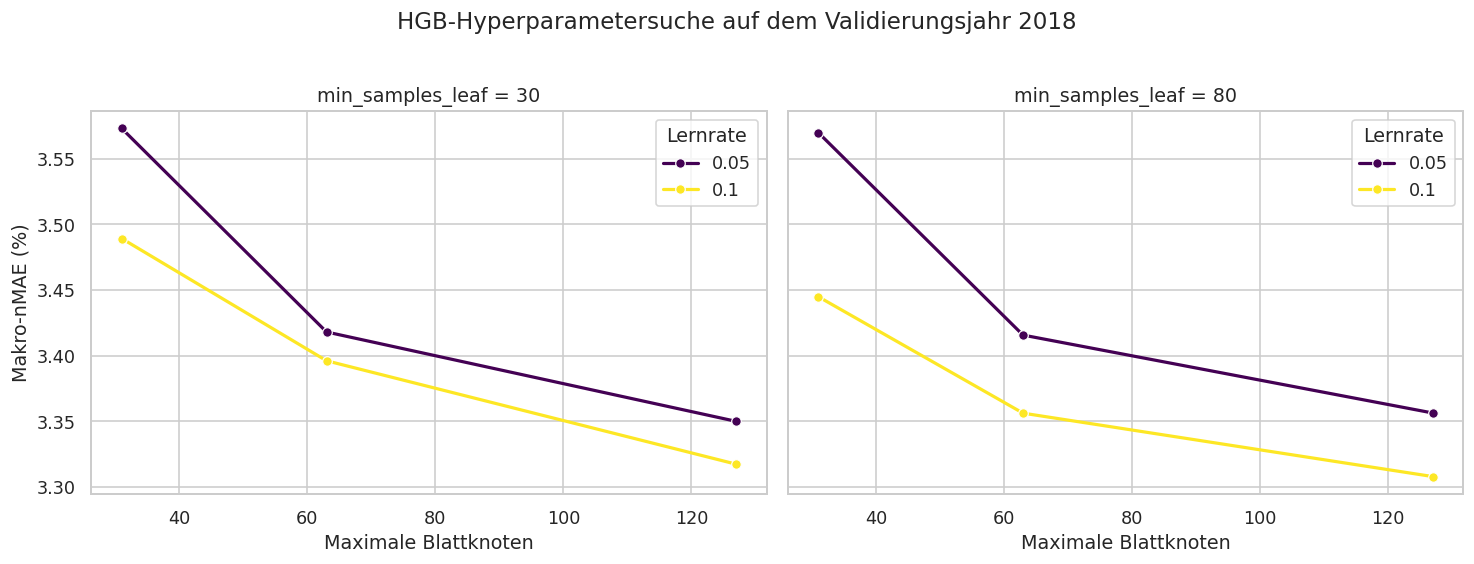

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.8), sharey=True)
for ax, min_leaf in zip(axes, (30, 80)):
    subset = hgb_results.loc[
        hgb_results["min_samples_leaf"].eq(min_leaf)
    ].copy()
    subset["macro_nMAE_pct"] = 100 * subset["macro_nMAE"]
    sns.lineplot(
        data=subset,
        x="max_leaf_nodes",
        y="macro_nMAE_pct",
        hue="learning_rate",
        marker="o",
        linewidth=2,
        palette="viridis",
        ax=ax,
    )
    ax.set(
        title=f"min_samples_leaf = {min_leaf}",
        xlabel="Maximale Blattknoten",
        ylabel="Makro-nMAE (%)" if min_leaf == 30 else "",
    )
    ax.legend(title="Lernrate")
fig.suptitle("HGB-Hyperparametersuche auf dem Validierungsjahr 2018", y=1.02)
plt.tight_layout()
plt.show()


## 8. Modellvergleich und Auswahl

Verglichen werden jetzt:

1. beide verpflichtenden Baselines,
2. der beste Ridge-Kandidat,
3. das kalenderbasierte HGB-Modell mit Feiertag,
4. der beste vollständige HGB-Kandidat.

Die Auswahl erfolgt ausschließlich nach Makro-nMAE auf 2018. Absolute MW-Werte,
sMAPE und R² dienen der ergänzenden Interpretation.


In [12]:
best_ridge_summary, best_ridge_by_country = record_prediction(
    "Ridge (beste Validierung)",
    best_ridge_prediction,
    family="Ridge",
    feature_set=best_ridge_row["feature_set"],
    fit_seconds=best_ridge_row["fit_seconds"],
)

hgb_calendar_model = ablation_models[(True, False)]
hgb_calendar_prediction = ablation_predictions[(True, False)]
hgb_calendar_summary, hgb_calendar_by_country = record_prediction(
    "HGB Kalender + Feiertag",
    hgb_calendar_prediction,
    family="Histogram Gradient Boosting",
    feature_set="Kalender + Feiertag",
    fit_seconds=float(
        ablation_results.loc[
            ablation_results["feature_set"].eq("Kalender + Feiertag"),
            "fit_seconds",
        ].iloc[0]
    ),
)

best_hgb_summary, best_hgb_by_country = record_prediction(
    "HGB Feiertag + Wetter",
    best_hgb_prediction,
    family="Histogram Gradient Boosting",
    feature_set="Kalender + Feiertag + Wetter",
    fit_seconds=best_hgb_row["fit_seconds"],
)

all_summaries.extend(
    [best_ridge_summary, hgb_calendar_summary, best_hgb_summary]
)
all_country_metrics.extend(
    [best_ridge_by_country, hgb_calendar_by_country, best_hgb_by_country]
)

comparison = pd.DataFrame(all_summaries).sort_values("macro_nMAE")
calendar_reference = float(calendar_summary["macro_nMAE"])
comparison["Verbesserung_vs_Kalender_pct"] = comparison["macro_nMAE"].map(
    lambda value: relative_improvement(value, calendar_reference)
)

display(
    format_frame(
        comparison[
            [
                "model",
                "feature_set",
                "MAE_MW",
                "RMSE_MW",
                "macro_nMAE",
                "sMAPE_pct",
                "R2",
                "Verbesserung_vs_Kalender_pct",
            ]
        ],
        {
            "MAE_MW": "{:,.1f}",
            "RMSE_MW": "{:,.1f}",
            "macro_nMAE": "{:.4f}",
            "sMAPE_pct": "{:.2f}",
            "R2": "{:.4f}",
            "Verbesserung_vs_Kalender_pct": "{:+.1f}",
        },
    )
)

print(
    "Ausgewählte Konfiguration: HGB mit "
    f"learning_rate={best_hgb_row['learning_rate']}, "
    f"max_leaf_nodes={int(best_hgb_row['max_leaf_nodes'])}, "
    f"min_samples_leaf={int(best_hgb_row['min_samples_leaf'])}."
)
print(
    "Validierungsverbesserung gegenüber Kalender-Baseline: "
    f"{relative_improvement(best_hgb_summary['macro_nMAE'], calendar_reference):.1f} %"
)


,model,feature_set,MAE_MW,RMSE_MW,macro_nMAE,sMAPE_pct,R2,Verbesserung_vs_Kalender_pct
4,HGB Feiertag + Wetter,Kalender + Feiertag + Wetter,"1,384.2","1,898.0",0.0331,3.35,0.9903,+42.5
3,HGB Kalender + Feiertag,Kalender + Feiertag,"2,175.3","3,564.8",0.0483,4.70,0.9657,+16.1
2,Ridge (beste Validierung),Kalender + Feiertag + Wetter,"2,132.0","2,989.7",0.0498,5.06,0.9759,+13.5
1,Kalender-Baseline,Land + Monat + Tagtyp + Stunde,"2,489.2","3,607.4",0.0576,5.76,0.9649,+0.0
0,Ländermittelwert,Land,"7,102.5","9,173.0",0.1597,16.09,0.7729,-177.4


Ausgewählte Konfiguration: HGB mit learning_rate=0.1, max_leaf_nodes=127, min_samples_leaf=80.
Validierungsverbesserung gegenüber Kalender-Baseline: 42.5 %


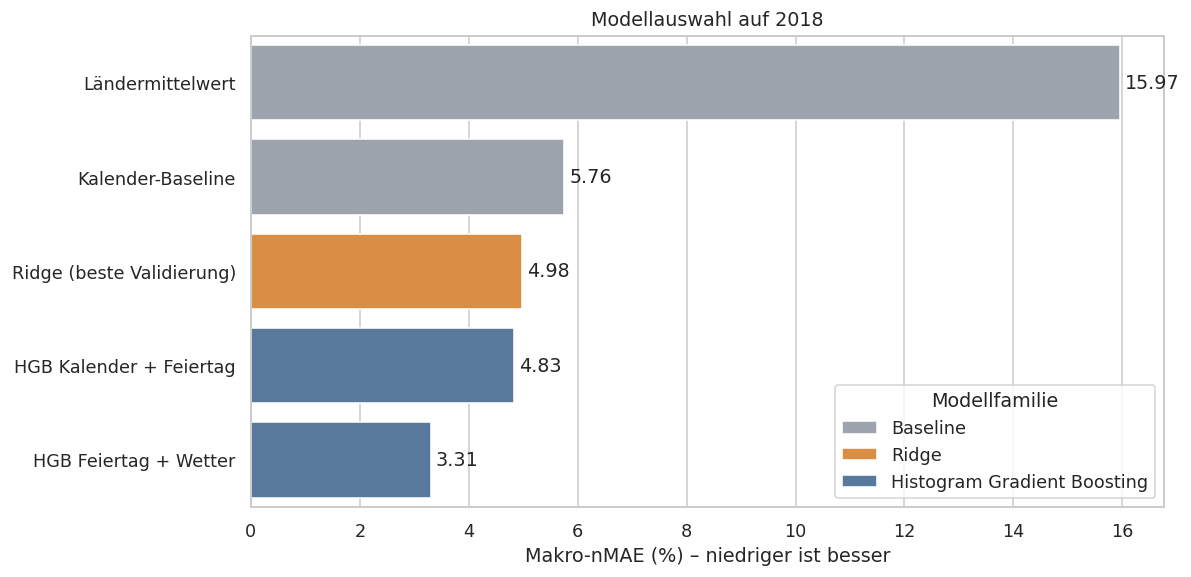

In [13]:
fig, ax = plt.subplots(figsize=(10.5, 5.2))
comparison_plot = comparison.sort_values("macro_nMAE", ascending=False).copy()
comparison_plot["macro_nMAE_pct"] = 100 * comparison_plot["macro_nMAE"]
sns.barplot(
    data=comparison_plot,
    y="model",
    x="macro_nMAE_pct",
    hue="family",
    dodge=False,
    palette={
        "Baseline": "#9ca3af",
        "Ridge": "#f28e2b",
        "Histogram Gradient Boosting": "#4c78a8",
    },
    ax=ax,
)
ax.set(
    title="Modellauswahl auf 2018",
    xlabel="Makro-nMAE (%) – niedriger ist besser",
    ylabel="",
)
for container in ax.containers:
    ax.bar_label(container, fmt="%.2f", padding=3)
ax.legend(title="Modellfamilie", loc="lower right")
plt.tight_layout()
plt.show()


## 9. Pflichtdiagnostik nach Land, Tageszeit und Saison

Ein guter Makrowert kann länderspezifische Schwächen verdecken. Deshalb wird
der ausgewählte Kandidat mindestens nach den drei im Q-Notebook festgelegten
Dimensionen untersucht.


,country,n,MAE_MW,RMSE_MW,nMAE,sMAPE_pct,R2,model
12,DE,8760,"1,714.1","2,154.8",0.0301,3.12,0.9523,HGB Feiertag + Wetter
13,FR,8749,"1,709.0","2,324.6",0.0318,3.11,0.9619,HGB Feiertag + Wetter
14,PL,8760,730.0,873.1,0.0374,3.82,0.9251,HGB Feiertag + Wetter


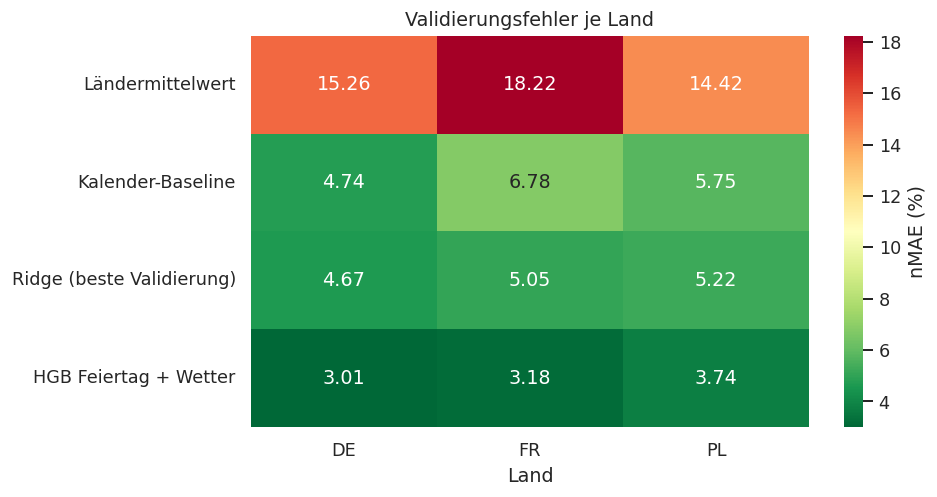

In [14]:
country_metrics = pd.concat(all_country_metrics, ignore_index=True)
selected_models = [
    "Ländermittelwert",
    "Kalender-Baseline",
    "Ridge (beste Validierung)",
    "HGB Feiertag + Wetter",
]
country_matrix = (
    country_metrics.loc[country_metrics["model"].isin(selected_models)]
    .pivot(index="model", columns="country", values="nMAE")
    .reindex(selected_models)
)

fig, ax = plt.subplots(figsize=(8.5, 4.5))
sns.heatmap(
    100 * country_matrix,
    annot=True,
    fmt=".2f",
    cmap="RdYlGn_r",
    cbar_kws={"label": "nMAE (%)"},
    ax=ax,
)
ax.set(
    title="Validierungsfehler je Land",
    xlabel="Land",
    ylabel="",
)
plt.tight_layout()
plt.show()

display(
    format_frame(
        country_metrics.loc[
            country_metrics["model"].eq("HGB Feiertag + Wetter")
        ],
        {
            "MAE_MW": "{:,.1f}",
            "RMSE_MW": "{:,.1f}",
            "nMAE": "{:.4f}",
            "sMAPE_pct": "{:.2f}",
            "R2": "{:.4f}",
        },
    )
)


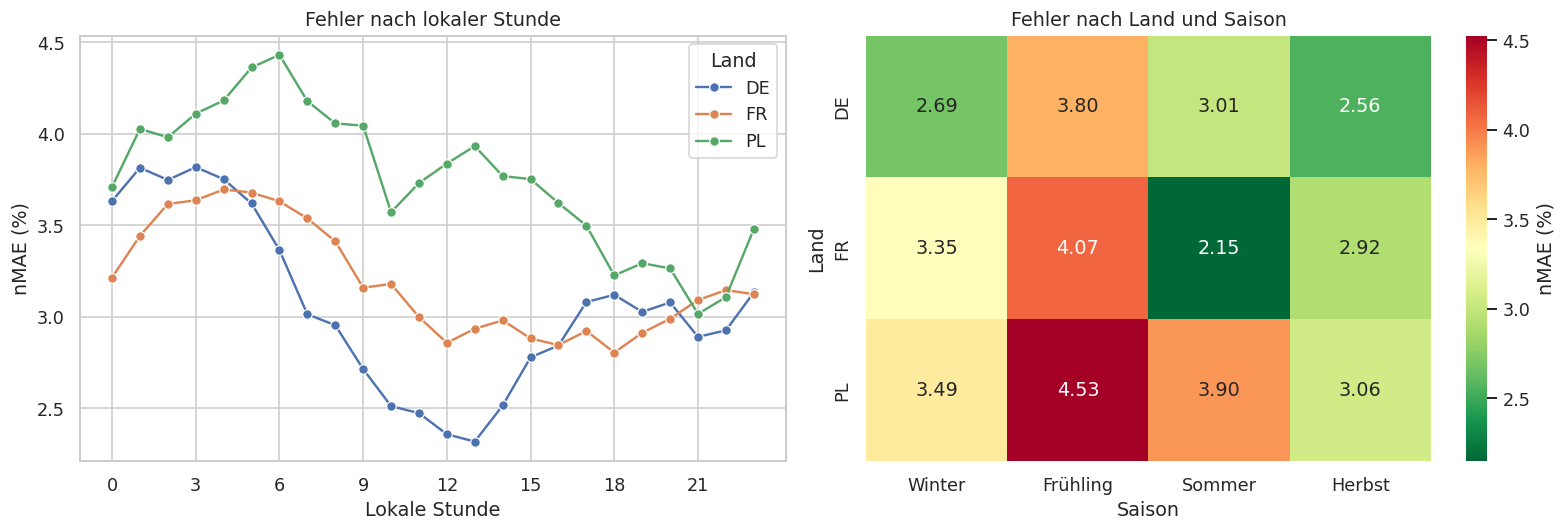

In [15]:
diagnostic = validation[
    [
        "utc_timestamp",
        "local_date",
        "country",
        "local_hour",
        "season",
        "load_mw",
    ]
].copy()
diagnostic["prediction_mw"] = best_hgb_prediction
diagnostic["residual_mw"] = (
    diagnostic["load_mw"] - diagnostic["prediction_mw"]
)
diagnostic["absolute_error_mw"] = diagnostic["residual_mw"].abs()

hour_diagnostic = (
    diagnostic.groupby(["country", "local_hour"], observed=True)
    .agg(
        MAE_MW=("absolute_error_mw", "mean"),
        mean_actual_mw=("load_mw", "mean"),
    )
    .reset_index()
)
hour_diagnostic["nMAE"] = (
    hour_diagnostic["MAE_MW"] / hour_diagnostic["mean_actual_mw"]
)

season_diagnostic = (
    diagnostic.groupby(["country", "season"], observed=True)
    .agg(
        MAE_MW=("absolute_error_mw", "mean"),
        mean_actual_mw=("load_mw", "mean"),
    )
    .reset_index()
)
season_diagnostic["nMAE"] = (
    season_diagnostic["MAE_MW"] / season_diagnostic["mean_actual_mw"]
)
season_order = ["Winter", "Frühling", "Sommer", "Herbst"]
season_matrix = (
    season_diagnostic.pivot(index="country", columns="season", values="nMAE")
    .reindex(columns=season_order)
)

fig, axes = plt.subplots(1, 2, figsize=(14, 4.8))
sns.lineplot(
    data=hour_diagnostic,
    x="local_hour",
    y=100 * hour_diagnostic["nMAE"],
    hue="country",
    marker="o",
    ax=axes[0],
)
axes[0].set(
    title="Fehler nach lokaler Stunde",
    xlabel="Lokale Stunde",
    ylabel="nMAE (%)",
    xticks=range(0, 24, 3),
)
axes[0].legend(title="Land")
sns.heatmap(
    100 * season_matrix,
    annot=True,
    fmt=".2f",
    cmap="RdYlGn_r",
    cbar_kws={"label": "nMAE (%)"},
    ax=axes[1],
)
axes[1].set(
    title="Fehler nach Land und Saison",
    xlabel="Saison",
    ylabel="Land",
)
plt.tight_layout()
plt.show()


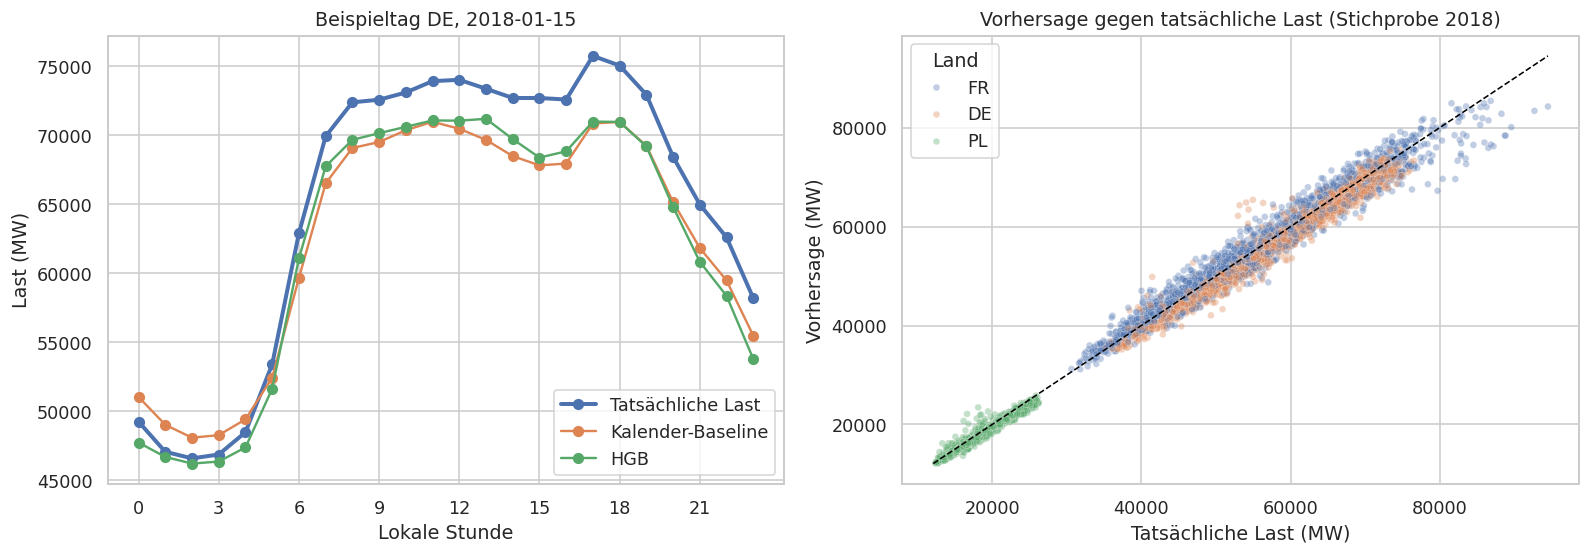

In [16]:
sample_date = "2018-01-15"
sample_country = "DE"
sample_mask = (
    validation["country"].eq(sample_country)
    & validation["local_date"].eq(sample_date)
)
sample = validation.loc[
    sample_mask,
    ["local_hour", "load_mw"],
].copy()
sample["Kalender-Baseline"] = calendar_prediction[sample_mask.to_numpy()]
sample["HGB"] = best_hgb_prediction[sample_mask.to_numpy()]
sample.sort_values("local_hour", inplace=True)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].plot(
    sample["local_hour"],
    sample["load_mw"],
    marker="o",
    linewidth=2.5,
    label="Tatsächliche Last",
)
axes[0].plot(
    sample["local_hour"],
    sample["Kalender-Baseline"],
    marker="o",
    label="Kalender-Baseline",
)
axes[0].plot(
    sample["local_hour"],
    sample["HGB"],
    marker="o",
    label="HGB",
)
axes[0].set(
    title=f"Beispieltag {sample_country}, {sample_date}",
    xlabel="Lokale Stunde",
    ylabel="Last (MW)",
    xticks=range(0, 24, 3),
)
axes[0].legend()

scatter_sample = diagnostic.sample(
    n=min(6000, len(diagnostic)),
    random_state=RANDOM_STATE,
)
sns.scatterplot(
    data=scatter_sample,
    x="load_mw",
    y="prediction_mw",
    hue="country",
    alpha=0.35,
    s=18,
    ax=axes[1],
)
limits = [
    min(scatter_sample["load_mw"].min(), scatter_sample["prediction_mw"].min()),
    max(scatter_sample["load_mw"].max(), scatter_sample["prediction_mw"].max()),
]
axes[1].plot(limits, limits, linestyle="--", color="black", linewidth=1)
axes[1].set(
    title="Vorhersage gegen tatsächliche Last (Stichprobe 2018)",
    xlabel="Tatsächliche Last (MW)",
    ylabel="Vorhersage (MW)",
)
axes[1].legend(title="Land")
plt.tight_layout()
plt.show()


## 10. Hypothesenstand nach A³

Die Ergebnisse von 2018 dürfen H2, H4 und H5 für die Entwicklungsphase
beurteilen. H3 betrifft ausdrücklich das finale, eingefrorene Modell auf 2019
und bleibt daher offen.


In [17]:
ridge_weather_error = float(best_ridge_summary["macro_nMAE"])
hgb_weather_error = float(best_hgb_summary["macro_nMAE"])
hgb_calendar_error = float(hgb_calendar_summary["macro_nMAE"])

hypothesis_results = pd.DataFrame(
    [
        {
            "Hypothese": "H2 – Kalenderstruktur",
            "A³-Befund 2018": (
                f"Kalender-Baseline verbessert Makro-nMAE um "
                f"{relative_improvement(calendar_summary['macro_nMAE'], mean_summary['macro_nMAE']):.1f} % "
                "gegenüber dem Ländermittel."
            ),
            "Status": "auf Validierung bestätigt",
        },
        {
            "Hypothese": "H3 – ML-Mehrwert",
            "A³-Befund 2018": (
                f"Ausgewähltes HGB verbessert Makro-nMAE um "
                f"{relative_improvement(hgb_weather_error, calendar_summary['macro_nMAE']):.1f} % "
                "gegenüber der Kalender-Baseline."
            ),
            "Status": "bis Test 2019 offen",
        },
        {
            "Hypothese": "H4 – Nichtlinearität",
            "A³-Befund 2018": (
                f"HGB verbessert Makro-nMAE um "
                f"{relative_improvement(hgb_weather_error, ridge_weather_error):.1f} % "
                "gegenüber dem besten Ridge-Modell."
            ),
            "Status": "auf Validierung bestätigt",
        },
        {
            "Hypothese": "H5 – Wetternutzen",
            "A³-Befund 2018": (
                f"HGB mit Wetter verbessert Makro-nMAE um "
                f"{relative_improvement(hgb_weather_error, hgb_calendar_error):.1f} % "
                "gegenüber HGB Kalender + Feiertag."
            ),
            "Status": "auf Validierung bestätigt",
        },
    ]
)
display(hypothesis_results)


,Hypothese,A³-Befund 2018,Status
0,H2 – Kalenderstruktur,Kalender-Baseline verbessert Makro-nMAE um 64.0 % gegenüber dem Ländermittel.,auf Validierung bestätigt
1,H3 – ML-Mehrwert,Ausgewähltes HGB verbessert Makro-nMAE um 42.5 % gegenüber der Kalender-Baseline.,bis Test 2019 offen
2,H4 – Nichtlinearität,HGB verbessert Makro-nMAE um 33.6 % gegenüber dem besten Ridge-Modell.,auf Validierung bestätigt
3,H5 – Wetternutzen,HGB mit Wetter verbessert Makro-nMAE um 31.5 % gegenüber HGB Kalender + Feiertag.,auf Validierung bestätigt


## 11. Konfiguration einfrieren

Gespeichert werden:

- die ausgewählte vollständige Inferenzpipeline als lokales `joblib`-Artefakt,
- eine kleine JSON-Spezifikation im Report-Ordner,
- Modellvergleich und Länderkennzahlen als CSV.

Das Binärmodell bleibt gemäß `.gitignore` lokal. Code, Parameter, Metriken und
Notebook-Ausgaben sind dagegen versionierbar und reproduzierbar.

Wichtig: Das gespeicherte A³-Modell ist nur auf 2015–2017 trainiert. In der
C-Phase wird die Konfiguration zunächst unverändert übernommen, anschließend
methodisch sauber auf Training plus Validierung refittet und genau einmal auf
2019 ausgewertet.


In [18]:
models_dir = PROJECT_ROOT / "models"
report_dir = PROJECT_ROOT / "reports" / "a3"
models_dir.mkdir(parents=True, exist_ok=True)
report_dir.mkdir(parents=True, exist_ok=True)

model_path = models_dir / "gridcast_a3_train_2015_2017.joblib"
selection_path = report_dir / "a3_selection.json"
comparison_path = report_dir / "validation_model_comparison.csv"
country_metrics_path = report_dir / "validation_metrics_by_country.csv"

joblib.dump(best_hgb_model, model_path, compress=3)

selection = {
    "project": "GridCast Europe",
    "phase": "A3",
    "selected_on": "validation_2018",
    "training_period": "2015-01-01/2017-12-31",
    "validation_period": "2018-01-01/2018-12-31",
    "test_period": "2019-01-01/2019-12-31",
    "test_used_in_selection": False,
    "countries": ["DE", "FR", "PL"],
    "primary_metric": "macro_nMAE",
    "model_family": "HistGradientBoostingRegressor",
    "target_scaling": "country_training_mean",
    "feature_set": "calendar + national_holiday + weather",
    "hyperparameters": {
        "loss": "absolute_error",
        "learning_rate": float(best_hgb_row["learning_rate"]),
        "max_leaf_nodes": int(best_hgb_row["max_leaf_nodes"]),
        "max_iter": int(best_hgb_row["max_iter"]),
        "min_samples_leaf": int(best_hgb_row["min_samples_leaf"]),
        "l2_regularization": float(best_hgb_row["l2_regularization"]),
        "early_stopping": False,
        "random_state": RANDOM_STATE,
    },
    "validation_metrics": {
        key: float(best_hgb_summary[key])
        for key in ["MAE_MW", "RMSE_MW", "macro_nMAE", "sMAPE_pct", "R2"]
    },
    "validation_improvement_vs_calendar_pct": relative_improvement(
        best_hgb_summary["macro_nMAE"],
        calendar_summary["macro_nMAE"],
    ),
}

selection_path.write_text(
    json.dumps(selection, ensure_ascii=False, indent=2) + "\n",
    encoding="utf-8",
)
comparison.to_csv(comparison_path, index=False)
country_metrics.to_csv(country_metrics_path, index=False)

artifact_summary = pd.DataFrame(
    [
        {
            "Artefakt": model_path.relative_to(PROJECT_ROOT),
            "Größe_KiB": model_path.stat().st_size / 1024,
            "Git": "ignoriert (lokal)",
        },
        {
            "Artefakt": selection_path.relative_to(PROJECT_ROOT),
            "Größe_KiB": selection_path.stat().st_size / 1024,
            "Git": "versionierbar",
        },
        {
            "Artefakt": comparison_path.relative_to(PROJECT_ROOT),
            "Größe_KiB": comparison_path.stat().st_size / 1024,
            "Git": "versionierbar",
        },
        {
            "Artefakt": country_metrics_path.relative_to(PROJECT_ROOT),
            "Größe_KiB": country_metrics_path.stat().st_size / 1024,
            "Git": "versionierbar",
        },
    ]
)
display(format_frame(artifact_summary, {"Größe_KiB": "{:,.1f}"}))


,Artefakt,Größe_KiB,Git
0,models/gridcast_a3_train_2015_2017.joblib,"1,873.8",ignoriert (lokal)
1,reports/a3/a3_selection.json,1.0,versionierbar
2,reports/a3/validation_model_comparison.csv,1.0,versionierbar
3,reports/a3/validation_metrics_by_country.csv,1.9,versionierbar


In [19]:
winner_nmae_pct = 100 * best_hgb_summary["macro_nMAE"]
improvement_pct = relative_improvement(
    best_hgb_summary["macro_nMAE"],
    calendar_summary["macro_nMAE"],
)

display(
    Markdown(
        f"""## 12. Abschluss der A³-Phase

Die A³-Phase wählt auf dem Validierungsjahr 2018 **Histogram Gradient
Boosting mit Kalender-, Feiertags- und Wettermerkmalen** aus.

- Makro-nMAE 2018: **{winner_nmae_pct:.2f} %**
- Verbesserung gegenüber der Kalender-Baseline: **{improvement_pct:.1f} %**
- praktisches 5-%-Ziel auf der Validierung: **erreicht**
- schwächstes Kernland bleibt anhand des nMAE: **{best_hgb_by_country.sort_values('nMAE', ascending=False).iloc[0]['country']}**
- Testjahr 2019 während Auswahl und Tuning verwendet: **nein**

Damit ist die Modellkonfiguration eingefroren. Der nächste Schritt ist
`03_conclude_compare.ipynb`: Refit auf 2015–2018, einmalige Auswertung auf
2019, endgültige Prüfung von H3 und danach Training des App-Modells.
"""
    )
)


## 12. Abschluss der A³-Phase

Die A³-Phase wählt auf dem Validierungsjahr 2018 **Histogram Gradient
Boosting mit Kalender-, Feiertags- und Wettermerkmalen** aus.

- Makro-nMAE 2018: **3.31 %**
- Verbesserung gegenüber der Kalender-Baseline: **42.5 %**
- praktisches 5-%-Ziel auf der Validierung: **erreicht**
- schwächstes Kernland bleibt anhand des nMAE: **PL**
- Testjahr 2019 während Auswahl und Tuning verwendet: **nein**

Damit ist die Modellkonfiguration eingefroren. Der nächste Schritt ist
`03_conclude_compare.ipynb`: Refit auf 2015–2018, einmalige Auswertung auf
2019, endgültige Prüfung von H3 und danach Training des App-Modells.
